# 04 — HCP Events and Targets

This notebook converts HCP event files into volume-aligned target representations for temporal modeling.

## Scope

This notebook does **not** extract ROI signals and does **not** build a PyTorch dataset.

It only handles:

```text
HCP EV text files
    ↓
event table
    ↓
volume-level boxcar representation
    ↓
fixed-lag labels
    ↓
canonical HRF-convolved regressors
    ↓
hard labels, masks, and saved metadata
```

## Outputs

For one subject-task-run, the notebook saves:

```text
events_long.tsv
condition_names.json
targets_boxcar.npy
targets_fixed_lag.npy
targets_hrf.npy
labels_fixed_lag.npy
labels_hrf.npy
valid_mask_fixed_lag.npy
valid_mask_hrf.npy
frame_times.npy
target_metadata.json
```

The target matrices have shape:

```text
n_timepoints × n_conditions
```

The hard-label vectors have shape:

```text
n_timepoints
```

Class `0` is reserved for baseline. Task conditions begin at class `1`.


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.glm.first_level import compute_regressor

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NiBabel:", nib.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
NiBabel: 5.4.2


## 1. Resolve project paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by searching upward."""
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the NeuroLens repository root."
    )


PROJECT_ROOT = find_project_root()

RAW_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "hcp_ya_s1200"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hcp_ya_s1200"
)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA_DIR)
print("Processed data:", PROCESSED_DATA_DIR)

Project root: /Users/srinivasgovindasurampudi/Projects/neurolens-rag
Raw data: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200
Processed data: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200


## 2. Run and target configuration

This default configuration targets one MOTOR run.

The event-file mapping is explicit so that cue or instruction files are not accidentally treated as task classes.


In [3]:
DATASET_RELEASE = "HCP-YA-S1200"

SUBJECT_ID = "100307"
TASK = "MOTOR"
RUN = "LR"

run_name = f"tfMRI_{TASK}_{RUN}"

run_dir = (
    RAW_DATA_DIR
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
    / run_name
)

func_path = run_dir / f"{run_name}.nii.gz"
events_dir = run_dir / "EVs"

output_dir = (
    PROCESSED_DATA_DIR
    / "targets"
    / f"sub-{SUBJECT_ID}"
    / run_name
)

output_dir.mkdir(parents=True, exist_ok=True)

# Explicit MOTOR event mapping.
# Adjust this dictionary for WM, EMOTION, or other tasks.
EVENT_FILE_TO_LABEL = {
    "lh.txt": "left_hand",
    "rh.txt": "right_hand",
    "lf.txt": "left_foot",
    "rf.txt": "right_foot",
    "t.txt": "tongue",
}

# Fixed hemodynamic delay for discrete labels.
HEMODYNAMIC_LAG_SECONDS = 5.0

# Canonical HRF model used by Nilearn.
HRF_MODEL = "spm"

# Convert HRF amplitudes into hard labels only when activation
# exceeds this fraction of the maximum value across the full run.
HRF_HARD_LABEL_THRESHOLD_FRACTION = 0.10

# Optional expansion of valid task periods around each event.
# Keep at zero initially.
PRE_EVENT_MARGIN_SECONDS = 0.0
POST_EVENT_MARGIN_SECONDS = 0.0

print("Functional file:", func_path)
print("Events directory:", events_dir)
print("Output directory:", output_dir)
print("Condition mapping:", EVENT_FILE_TO_LABEL)

Functional file: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz
Events directory: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs
Output directory: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR
Condition mapping: {'lh.txt': 'left_hand', 'rh.txt': 'right_hand', 'lf.txt': 'left_foot', 'rf.txt': 'right_foot', 't.txt': 'tongue'}


## 3. Validate inputs and read run timing

In [4]:
if not func_path.exists():
    raise FileNotFoundError(
        f"Functional NIfTI not found: {func_path}"
    )

if not events_dir.exists():
    raise FileNotFoundError(
        f"Event directory not found: {events_dir}"
    )

missing_event_files = [
    filename
    for filename in EVENT_FILE_TO_LABEL
    if not (events_dir / filename).exists()
]

if missing_event_files:
    raise FileNotFoundError(
        "Missing expected event files: "
        + ", ".join(missing_event_files)
    )

img = nib.load(func_path)

if len(img.shape) != 4:
    raise ValueError(
        f"Expected a 4D fMRI image, got {img.shape}."
    )

n_timepoints = int(img.shape[-1])
tr_seconds = float(img.header.get_zooms()[3])
run_duration_seconds = n_timepoints * tr_seconds

# Use acquisition times beginning at zero.
frame_times = np.arange(n_timepoints, dtype=np.float64) * tr_seconds

print("NIfTI shape:", img.shape)
print("Time points:", n_timepoints)
print("TR (seconds):", tr_seconds)
print("Run duration (seconds):", run_duration_seconds)
print("Final frame time:", frame_times[-1])

NIfTI shape: (91, 109, 91, 284)
Time points: 284
TR (seconds): 0.7200000286102295
Run duration (seconds): 204.48000812530518
Final frame time: 203.76000809669495


## 4. Read HCP EV files

HCP EV files are treated as three-column text files:

```text
onset_seconds  duration_seconds  amplitude
```


In [5]:
def read_hcp_event_file(
    path: Path,
    *,
    condition: str,
) -> pd.DataFrame:
    """Read one HCP EV file into a normalized event table."""
    events = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["onset", "duration", "amplitude"],
        usecols=[0, 1, 2],
        dtype=float,
    )

    if events.empty:
        raise ValueError(f"Event file is empty: {path}")

    if not np.isfinite(
        events[["onset", "duration", "amplitude"]].to_numpy()
    ).all():
        raise ValueError(
            f"Event file contains non-finite values: {path}"
        )

    if (events["onset"] < 0).any():
        raise ValueError(
            f"Negative event onset found in {path}"
        )

    if (events["duration"] <= 0).any():
        raise ValueError(
            f"Non-positive event duration found in {path}"
        )

    events["condition"] = condition
    events["source_file"] = path.name
    events["offset"] = events["onset"] + events["duration"]

    return events


event_frames: list[pd.DataFrame] = []

for filename, condition in EVENT_FILE_TO_LABEL.items():
    event_frames.append(
        read_hcp_event_file(
            events_dir / filename,
            condition=condition,
        )
    )

events_df = (
    pd.concat(event_frames, ignore_index=True)
    .sort_values(["onset", "condition"])
    .reset_index(drop=True)
)

events_df

,onset,duration,amplitude,condition,source_file,offset
0,11.009,12.0,1.0,right_hand,rh.txt,23.009
1,26.136,12.0,1.0,left_foot,lf.txt,38.136
2,41.264,12.0,1.0,tongue,t.txt,53.264
3,56.391,12.0,1.0,right_foot,rf.txt,68.391
4,71.518,12.0,1.0,left_hand,lh.txt,83.518
5,101.639,12.0,1.0,tongue,t.txt,113.639
6,116.766,12.0,1.0,left_foot,lf.txt,128.766
7,131.894,12.0,1.0,right_hand,rh.txt,143.894
8,162.015,12.0,1.0,left_hand,lh.txt,174.015
9,177.142,12.0,1.0,right_foot,rf.txt,189.142


## 5. Validate event timing

In [6]:
timing_checks = {
    "event_count": int(len(events_df)),
    "minimum_onset": float(events_df["onset"].min()),
    "maximum_offset": float(events_df["offset"].max()),
    "run_duration_seconds": float(run_duration_seconds),
    "events_end_within_run": bool(
        events_df["offset"].max() <= run_duration_seconds + tr_seconds
    ),
    "condition_count": int(events_df["condition"].nunique()),
}

print(json.dumps(timing_checks, indent=2))

if not timing_checks["events_end_within_run"]:
    raise ValueError(
        "At least one event extends beyond the run duration."
    )

condition_summary = (
    events_df
    .groupby("condition", as_index=False)
    .agg(
        event_count=("condition", "size"),
        total_duration_seconds=("duration", "sum"),
        first_onset=("onset", "min"),
        final_offset=("offset", "max"),
    )
)

condition_summary

{
  "event_count": 10,
  "minimum_onset": 11.009,
  "maximum_offset": 189.142,
  "run_duration_seconds": 204.48000812530518,
  "events_end_within_run": true,
  "condition_count": 5
}


,condition,event_count,total_duration_seconds,first_onset,final_offset
0,left_foot,2,24.0,26.136,128.766
1,left_hand,2,24.0,71.518,174.015
2,right_foot,2,24.0,56.391,189.142
3,right_hand,2,24.0,11.009,143.894
4,tongue,2,24.0,41.264,113.639


## 6. Define condition order and class mapping

In [7]:
condition_names = list(EVENT_FILE_TO_LABEL.values())

if len(condition_names) != len(set(condition_names)):
    raise ValueError("Condition labels must be unique.")

condition_to_column = {
    condition: index
    for index, condition in enumerate(condition_names)
}

# Class zero is baseline.
condition_to_class = {
    condition: index + 1
    for index, condition in enumerate(condition_names)
}

class_to_condition = {
    0: "baseline",
    **{
        class_id: condition
        for condition, class_id in condition_to_class.items()
    },
}

print("Condition columns:", condition_to_column)
print("Class mapping:", condition_to_class)
print("Inverse mapping:", class_to_condition)

Condition columns: {'left_hand': 0, 'right_hand': 1, 'left_foot': 2, 'right_foot': 3, 'tongue': 4}
Class mapping: {'left_hand': 1, 'right_hand': 2, 'left_foot': 3, 'right_foot': 4, 'tongue': 5}
Inverse mapping: {0: 'baseline', 1: 'left_hand', 2: 'right_hand', 3: 'left_foot', 4: 'right_foot', 5: 'tongue'}


## 7. Create an unshifted volume-level boxcar matrix

A volume is marked active when its acquisition time falls inside an event interval.

This is the neural-event representation before accounting for the delayed BOLD response.


In [8]:
def events_to_boxcar_matrix(
    events: pd.DataFrame,
    *,
    frame_times: np.ndarray,
    condition_to_column: dict[str, int],
) -> np.ndarray:
    """Convert continuous event intervals into a multi-hot volume matrix."""
    matrix = np.zeros(
        (len(frame_times), len(condition_to_column)),
        dtype=np.float32,
    )

    for event in events.itertuples(index=False):
        column = condition_to_column[event.condition]

        active = (
            (frame_times >= float(event.onset))
            & (frame_times < float(event.offset))
        )

        matrix[active, column] = float(event.amplitude)

    return matrix


targets_boxcar = events_to_boxcar_matrix(
    events_df,
    frame_times=frame_times,
    condition_to_column=condition_to_column,
)

print("Boxcar target shape:", targets_boxcar.shape)
print(
    "Active volumes by condition:",
    dict(
        zip(
            condition_names,
            (targets_boxcar > 0).sum(axis=0).tolist(),
        )
    ),
)

Boxcar target shape: (284, 5)
Active volumes by condition: {'left_hand': 32, 'right_hand': 32, 'left_foot': 32, 'right_foot': 32, 'tongue': 32}


## 8. Create fixed-lag targets

In [9]:
def shift_target_matrix(
    matrix: np.ndarray,
    *,
    lag_volumes: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Shift targets forward in time and return a validity mask."""
    if lag_volumes < 0:
        raise ValueError("lag_volumes must be non-negative.")

    shifted = np.zeros_like(matrix)
    valid_mask = np.ones(matrix.shape[0], dtype=bool)

    if lag_volumes == 0:
        return shifted + matrix, valid_mask

    if lag_volumes >= matrix.shape[0]:
        raise ValueError(
            "Hemodynamic lag is longer than the entire run."
        )

    shifted[lag_volumes:] = matrix[:-lag_volumes]

    # Initial shifted volumes have no corresponding pre-lag neural event.
    valid_mask[:lag_volumes] = False

    return shifted, valid_mask


lag_volumes = int(
    round(HEMODYNAMIC_LAG_SECONDS / tr_seconds)
)
effective_lag_seconds = lag_volumes * tr_seconds

targets_fixed_lag, valid_mask_fixed_lag = shift_target_matrix(
    targets_boxcar,
    lag_volumes=lag_volumes,
)

print("Requested lag (seconds):", HEMODYNAMIC_LAG_SECONDS)
print("Lag (volumes):", lag_volumes)
print("Effective lag (seconds):", effective_lag_seconds)
print(
    "Valid fixed-lag volumes:",
    int(valid_mask_fixed_lag.sum()),
)

Requested lag (seconds): 5.0
Lag (volumes): 7
Effective lag (seconds): 5.0400002002716064
Valid fixed-lag volumes: 277


## 9. Create canonical HRF-convolved regressors

In [10]:
def events_to_hrf_matrix(
    events: pd.DataFrame,
    *,
    frame_times: np.ndarray,
    condition_names: list[str],
    hrf_model: str,
) -> np.ndarray:
    """Convolve each condition with a canonical HRF."""
    columns: list[np.ndarray] = []

    for condition in condition_names:
        condition_events = events[
            events["condition"] == condition
        ]

        experimental_condition = np.vstack(
            [
                condition_events["onset"].to_numpy(dtype=float),
                condition_events["duration"].to_numpy(dtype=float),
                condition_events["amplitude"].to_numpy(dtype=float),
            ]
        )

        regressor, regressor_names = compute_regressor(
            experimental_condition,
            hrf_model=hrf_model,
            frame_times=frame_times,
            con_id=condition,
        )

        if regressor.shape[1] != 1:
            raise ValueError(
                f"Expected one HRF regressor for {condition}, "
                f"got {regressor_names}."
            )

        columns.append(regressor[:, 0])

    matrix = np.column_stack(columns).astype(np.float32)

    if not np.isfinite(matrix).all():
        raise ValueError(
            "HRF target matrix contains non-finite values."
        )

    return matrix


targets_hrf = events_to_hrf_matrix(
    events_df,
    frame_times=frame_times,
    condition_names=condition_names,
    hrf_model=HRF_MODEL,
)

print("HRF target shape:", targets_hrf.shape)
print(
    "HRF maxima:",
    dict(
        zip(
            condition_names,
            targets_hrf.max(axis=0).tolist(),
        )
    ),
)

HRF target shape: (284, 5)
HRF maxima: {'left_hand': 1.144710898399353, 'right_hand': 1.1447362899780273, 'left_foot': 1.144730567932129, 'right_foot': 1.1447219848632812, 'tongue': 1.1447298526763916}


## 10. Convert continuous targets to hard labels

Two hard-label vectors are created:

- `labels_fixed_lag`: derived from the fixed-lag boxcar matrix;
- `labels_hrf`: derived from the strongest HRF regressor.

A volume is assigned baseline class `0` when no task condition is sufficiently active.


In [11]:
def multi_condition_matrix_to_labels(
    matrix: np.ndarray,
    *,
    activation_threshold: float | np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Convert a condition matrix to baseline-plus-condition labels."""
    if matrix.ndim != 2:
        raise ValueError("Target matrix must be 2D.")

    winning_columns = np.argmax(matrix, axis=1)
    winning_values = np.max(matrix, axis=1)

    labels = winning_columns.astype(np.int64) + 1

    threshold = np.asarray(activation_threshold)
    active_mask = winning_values > threshold

    labels[~active_mask] = 0

    return labels, active_mask


labels_fixed_lag, task_mask_fixed_lag = (
    multi_condition_matrix_to_labels(
        targets_fixed_lag,
        activation_threshold=0.0,
    )
)

global_hrf_max = float(np.max(targets_hrf))
hrf_hard_threshold = (
    HRF_HARD_LABEL_THRESHOLD_FRACTION
    * global_hrf_max
)

labels_hrf, task_mask_hrf = (
    multi_condition_matrix_to_labels(
        targets_hrf,
        activation_threshold=hrf_hard_threshold,
    )
)

# Valid mask represents usable temporal alignment.
# Task mask represents whether a non-baseline class is active.
valid_mask_hrf = np.ones(n_timepoints, dtype=bool)

print("HRF hard-label threshold:", hrf_hard_threshold)
print(
    "Fixed-lag labeled task volumes:",
    int(task_mask_fixed_lag.sum()),
)
print(
    "HRF labeled task volumes:",
    int(task_mask_hrf.sum()),
)

HRF hard-label threshold: 0.11447362899780274
Fixed-lag labeled task volumes: 160
HRF labeled task volumes: 216


## 11. Check for ambiguous or overlapping conditions

In [12]:
boxcar_overlap_count = int(
    ((targets_boxcar > 0).sum(axis=1) > 1).sum()
)

fixed_lag_overlap_count = int(
    ((targets_fixed_lag > 0).sum(axis=1) > 1).sum()
)

hrf_overlap_count = int(
    (
        (targets_hrf > hrf_hard_threshold)
        .sum(axis=1)
        > 1
    ).sum()
)

overlap_summary = {
    "boxcar_multi_condition_volumes": boxcar_overlap_count,
    "fixed_lag_multi_condition_volumes": fixed_lag_overlap_count,
    "hrf_above_threshold_multi_condition_volumes": hrf_overlap_count,
}

overlap_summary

{'boxcar_multi_condition_volumes': 0,
 'fixed_lag_multi_condition_volumes': 0,
 'hrf_above_threshold_multi_condition_volumes': 14}

## 12. Optional event-period mask with margins

This mask can later restrict training to task-relevant periods while preserving a configurable amount of surrounding context.

It is not applied automatically to the saved labels.


In [13]:
def build_event_period_mask(
    events: pd.DataFrame,
    *,
    frame_times: np.ndarray,
    pre_margin_seconds: float,
    post_margin_seconds: float,
) -> np.ndarray:
    mask = np.zeros(len(frame_times), dtype=bool)

    for event in events.itertuples(index=False):
        start = max(
            0.0,
            float(event.onset) - pre_margin_seconds,
        )
        stop = (
            float(event.offset)
            + post_margin_seconds
        )

        mask |= (
            (frame_times >= start)
            & (frame_times < stop)
        )

    return mask


event_period_mask = build_event_period_mask(
    events_df,
    frame_times=frame_times,
    pre_margin_seconds=PRE_EVENT_MARGIN_SECONDS,
    post_margin_seconds=POST_EVENT_MARGIN_SECONDS,
)

print(
    "Volumes inside event-period mask:",
    int(event_period_mask.sum()),
)

Volumes inside event-period mask: 160


## 13. Class-balance summaries

In [14]:
def summarize_labels(
    labels: np.ndarray,
    *,
    class_to_condition: dict[int, str],
    name: str,
) -> pd.DataFrame:
    values, counts = np.unique(
        labels,
        return_counts=True,
    )

    rows = []

    for value, count in zip(values, counts):
        rows.append(
            {
                "representation": name,
                "class_id": int(value),
                "class_name": class_to_condition[int(value)],
                "volume_count": int(count),
                "fraction": float(count / len(labels)),
            }
        )

    return pd.DataFrame(rows)


class_balance_df = pd.concat(
    [
        summarize_labels(
            labels_fixed_lag,
            class_to_condition=class_to_condition,
            name="fixed_lag",
        ),
        summarize_labels(
            labels_hrf,
            class_to_condition=class_to_condition,
            name="hrf",
        ),
    ],
    ignore_index=True,
)

class_balance_df

,representation,class_id,class_name,volume_count,fraction
0,fixed_lag,0,baseline,124,0.436620
1,fixed_lag,1,left_hand,32,0.112676
2,fixed_lag,2,right_hand,32,0.112676
3,fixed_lag,3,left_foot,32,0.112676
4,fixed_lag,4,right_foot,32,0.112676
5,fixed_lag,5,tongue,32,0.112676
6,hrf,0,baseline,68,0.239437
7,hrf,1,left_hand,44,0.154930
8,hrf,2,right_hand,44,0.154930
9,hrf,3,left_foot,42,0.147887


## 14. Visualize boxcar, fixed-lag, and HRF targets

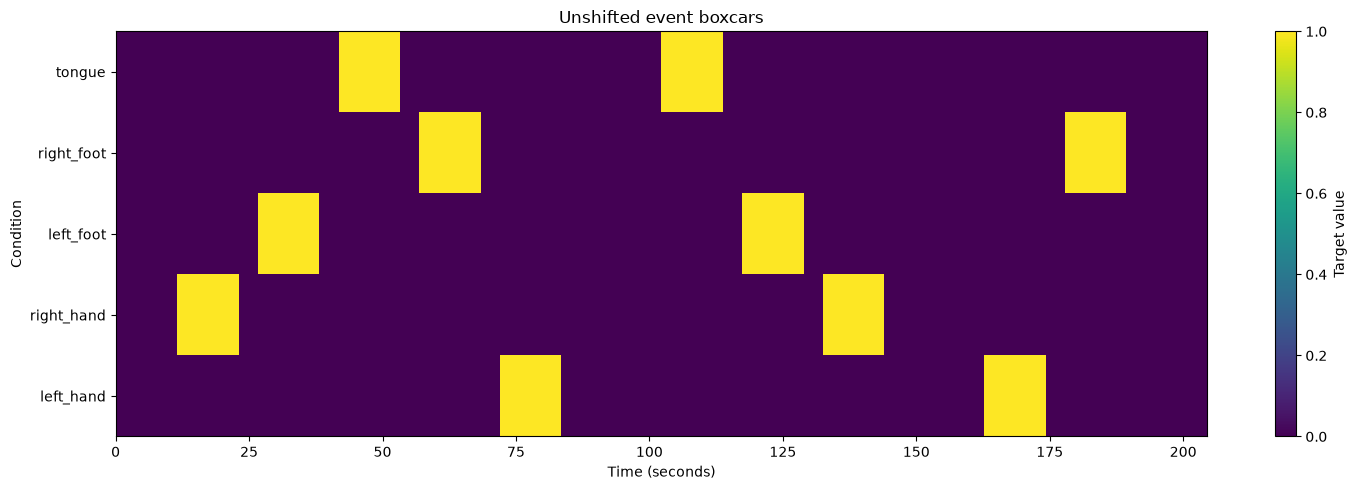

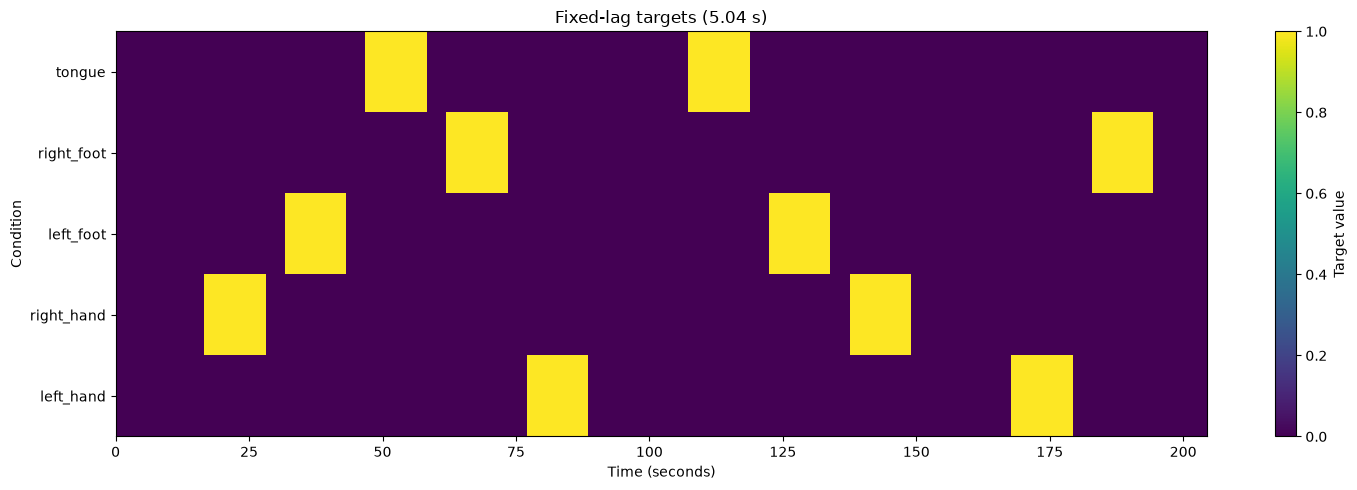

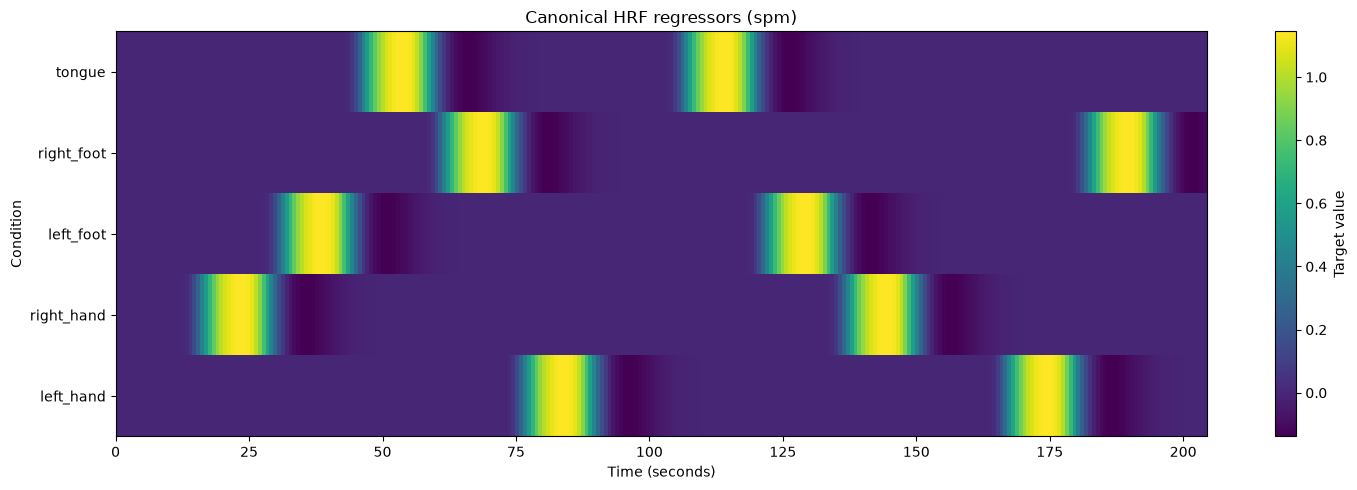

In [15]:
def plot_target_matrix(
    matrix: np.ndarray,
    *,
    frame_times: np.ndarray,
    condition_names: list[str],
    title: str,
) -> None:
    plt.figure(figsize=(15, 5))

    plt.imshow(
        matrix.T,
        aspect="auto",
        origin="lower",
        extent=[
            frame_times[0],
            frame_times[-1] + tr_seconds,
            -0.5,
            len(condition_names) - 0.5,
        ],
    )

    plt.yticks(
        np.arange(len(condition_names)),
        condition_names,
    )
    plt.xlabel("Time (seconds)")
    plt.ylabel("Condition")
    plt.title(title)
    plt.colorbar(label="Target value")
    plt.tight_layout()
    plt.show()


plot_target_matrix(
    targets_boxcar,
    frame_times=frame_times,
    condition_names=condition_names,
    title="Unshifted event boxcars",
)

plot_target_matrix(
    targets_fixed_lag,
    frame_times=frame_times,
    condition_names=condition_names,
    title=(
        "Fixed-lag targets "
        f"({effective_lag_seconds:.2f} s)"
    ),
)

plot_target_matrix(
    targets_hrf,
    frame_times=frame_times,
    condition_names=condition_names,
    title=f"Canonical HRF regressors ({HRF_MODEL})",
)

## 15. Visualize hard labels

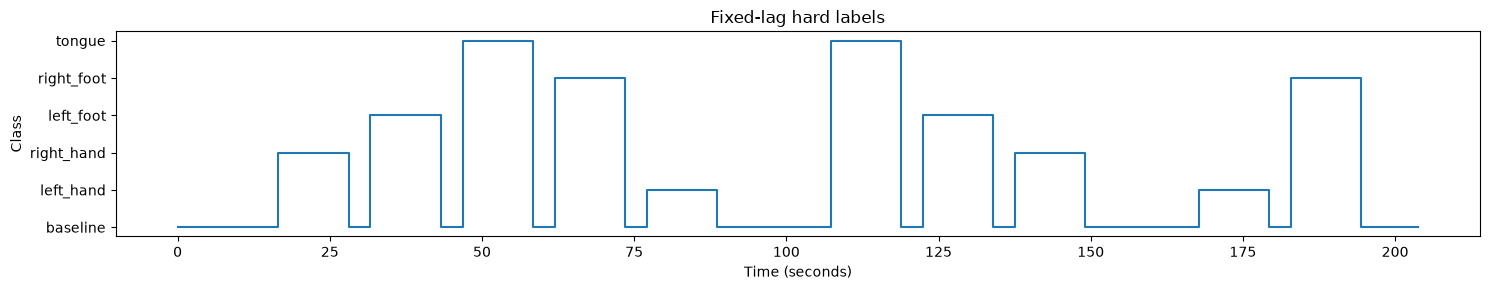

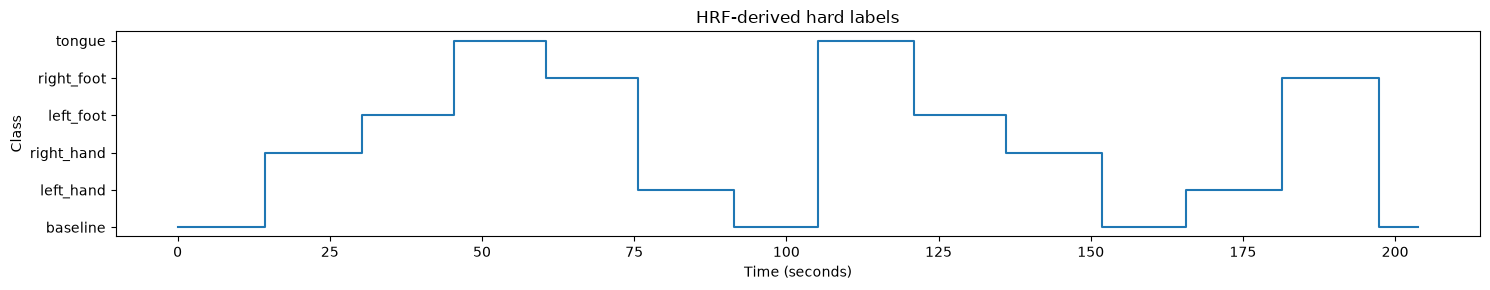

In [16]:
plt.figure(figsize=(15, 3))
plt.step(
    frame_times,
    labels_fixed_lag,
    where="post",
)
plt.yticks(
    list(class_to_condition.keys()),
    list(class_to_condition.values()),
)
plt.xlabel("Time (seconds)")
plt.ylabel("Class")
plt.title("Fixed-lag hard labels")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 3))
plt.step(
    frame_times,
    labels_hrf,
    where="post",
)
plt.yticks(
    list(class_to_condition.keys()),
    list(class_to_condition.values()),
)
plt.xlabel("Time (seconds)")
plt.ylabel("Class")
plt.title("HRF-derived hard labels")
plt.tight_layout()
plt.show()

## 16. Compare fixed-lag and HRF labels

In [17]:
label_agreement = labels_fixed_lag == labels_hrf

comparison = {
    "overall_agreement_fraction": float(
        label_agreement.mean()
    ),
    "agreement_volume_count": int(
        label_agreement.sum()
    ),
    "fixed_lag_task_volume_count": int(
        (labels_fixed_lag > 0).sum()
    ),
    "hrf_task_volume_count": int(
        (labels_hrf > 0).sum()
    ),
}

comparison

{'overall_agreement_fraction': 0.8028169014084507,
 'agreement_volume_count': 228,
 'fixed_lag_task_volume_count': 160,
 'hrf_task_volume_count': 216}

In [18]:
comparison_table = pd.crosstab(
    pd.Series(
        labels_fixed_lag,
        name="fixed_lag_class",
    ),
    pd.Series(
        labels_hrf,
        name="hrf_class",
    ),
)

comparison_table

hrf_class,0,1,2,3,4,5
fixed_lag_class,,,,,,
0,68,12,12,10,11,11
1,0,32,0,0,0,0
2,0,0,32,0,0,0
3,0,0,0,32,0,0
4,0,0,0,0,32,0
5,0,0,0,0,0,32


## 17. Save event table and condition metadata

In [19]:
events_path = output_dir / "events_long.tsv"

events_df.to_csv(
    events_path,
    sep="\t",
    index=False,
)

condition_metadata = {
    "condition_names": condition_names,
    "condition_to_column": condition_to_column,
    "condition_to_class": condition_to_class,
    "class_to_condition": {
        str(key): value
        for key, value in class_to_condition.items()
    },
    "event_file_to_label": EVENT_FILE_TO_LABEL,
}

condition_names_path = (
    output_dir
    / "condition_names.json"
)

condition_names_path.write_text(
    json.dumps(condition_metadata, indent=2),
    encoding="utf-8",
)

print("Saved:", events_path)
print("Saved:", condition_names_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/events_long.tsv
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/condition_names.json


## 18. Save target arrays

In [20]:
output_arrays = {
    "frame_times.npy": frame_times.astype(np.float32),
    "targets_boxcar.npy": targets_boxcar.astype(np.float32),
    "targets_fixed_lag.npy": targets_fixed_lag.astype(np.float32),
    "targets_hrf.npy": targets_hrf.astype(np.float32),
    "labels_fixed_lag.npy": labels_fixed_lag.astype(np.int64),
    "labels_hrf.npy": labels_hrf.astype(np.int64),
    "valid_mask_fixed_lag.npy": valid_mask_fixed_lag.astype(bool),
    "valid_mask_hrf.npy": valid_mask_hrf.astype(bool),
    "task_mask_fixed_lag.npy": task_mask_fixed_lag.astype(bool),
    "task_mask_hrf.npy": task_mask_hrf.astype(bool),
    "event_period_mask.npy": event_period_mask.astype(bool),
}

for filename, array in output_arrays.items():
    path = output_dir / filename
    np.save(path, array)
    print("Saved:", path, array.shape, array.dtype)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/frame_times.npy (284,) float32
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/targets_boxcar.npy (284, 5) float32
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/targets_fixed_lag.npy (284, 5) float32
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/targets_hrf.npy (284, 5) float32
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/labels_fixed_lag.npy (284,) int64
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/labels_hrf.npy (284,) int64
Saved: /Users/srinivasgovindasurampudi/Projects/neurole

## 19. Save volume-level table

In [21]:
volume_targets_df = pd.DataFrame(
    {
        "volume_index": np.arange(n_timepoints),
        "frame_time_seconds": frame_times,
        "label_fixed_lag": labels_fixed_lag,
        "label_hrf": labels_hrf,
        "valid_fixed_lag": valid_mask_fixed_lag,
        "valid_hrf": valid_mask_hrf,
        "task_fixed_lag": task_mask_fixed_lag,
        "task_hrf": task_mask_hrf,
        "event_period": event_period_mask,
    }
)

for column_index, condition in enumerate(condition_names):
    volume_targets_df[
        f"boxcar_{condition}"
    ] = targets_boxcar[:, column_index]

    volume_targets_df[
        f"fixed_lag_{condition}"
    ] = targets_fixed_lag[:, column_index]

    volume_targets_df[
        f"hrf_{condition}"
    ] = targets_hrf[:, column_index]

volume_targets_path = (
    output_dir
    / "volume_targets.tsv"
)

volume_targets_df.to_csv(
    volume_targets_path,
    sep="\t",
    index=False,
)

print("Saved:", volume_targets_path)
volume_targets_df.head()

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/volume_targets.tsv


,volume_index,frame_time_seconds,label_fixed_lag,label_hrf,valid_fixed_lag,valid_hrf,task_fixed_lag,task_hrf,event_period,boxcar_left_hand,fixed_lag_left_hand,hrf_left_hand,boxcar_right_hand,fixed_lag_right_hand,hrf_right_hand,boxcar_left_foot,fixed_lag_left_foot,hrf_left_foot,boxcar_right_foot,fixed_lag_right_foot,hrf_right_foot,boxcar_tongue,fixed_lag_tongue,hrf_tongue
0,0,0.00,0,0,False,True,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.72,0,0,False,True,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,1.44,0,0,False,True,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,2.16,0,0,False,True,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,2.88,0,0,False,True,False,False,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 20. Save target metadata

In [22]:
target_metadata: dict[str, Any] = {
    "dataset_release": DATASET_RELEASE,
    "subject_id": SUBJECT_ID,
    "task": TASK,
    "run": RUN,
    "run_name": run_name,
    "source_nifti": str(
        func_path.relative_to(PROJECT_ROOT)
    ),
    "events_directory": str(
        events_dir.relative_to(PROJECT_ROOT)
    ),
    "n_timepoints": n_timepoints,
    "tr_seconds": tr_seconds,
    "run_duration_seconds": run_duration_seconds,
    "conditions": condition_metadata,
    "fixed_lag": {
        "requested_lag_seconds": HEMODYNAMIC_LAG_SECONDS,
        "lag_volumes": lag_volumes,
        "effective_lag_seconds": effective_lag_seconds,
        "initial_invalid_volume_count": lag_volumes,
    },
    "hrf": {
        "model": HRF_MODEL,
        "hard_label_threshold_fraction": (
            HRF_HARD_LABEL_THRESHOLD_FRACTION
        ),
        "hard_label_threshold_value": hrf_hard_threshold,
    },
    "event_period_mask": {
        "pre_event_margin_seconds": PRE_EVENT_MARGIN_SECONDS,
        "post_event_margin_seconds": POST_EVENT_MARGIN_SECONDS,
    },
    "timing_checks": timing_checks,
    "overlap_summary": overlap_summary,
    "label_comparison": comparison,
    "array_shapes": {
        filename: list(array.shape)
        for filename, array in output_arrays.items()
    },
}

target_metadata_path = (
    output_dir
    / "target_metadata.json"
)

target_metadata_path.write_text(
    json.dumps(target_metadata, indent=2),
    encoding="utf-8",
)

print("Saved:", target_metadata_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/targets/sub-100307/tfMRI_MOTOR_LR/target_metadata.json


## 21. Reload and alignment verification

In [23]:
reloaded_fixed_lag = np.load(
    output_dir / "targets_fixed_lag.npy"
)

reloaded_hrf = np.load(
    output_dir / "targets_hrf.npy"
)

reloaded_labels_fixed = np.load(
    output_dir / "labels_fixed_lag.npy"
)

reloaded_labels_hrf = np.load(
    output_dir / "labels_hrf.npy"
)

assert reloaded_fixed_lag.shape == (
    n_timepoints,
    len(condition_names),
)

assert reloaded_hrf.shape == (
    n_timepoints,
    len(condition_names),
)

assert reloaded_labels_fixed.shape == (
    n_timepoints,
)

assert reloaded_labels_hrf.shape == (
    n_timepoints,
)

roi_timeseries_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hcp_ya_s1200"
    / "roi_timeseries"
    / f"sub-{SUBJECT_ID}"
    / run_name
    / "roi_timeseries_motion_cleaned.npy"
)

if roi_timeseries_path.exists():
    roi_timeseries = np.load(
        roi_timeseries_path,
        mmap_mode="r",
    )

    if roi_timeseries.shape[0] != n_timepoints:
        raise ValueError(
            "ROI time series and targets have different "
            f"time dimensions: {roi_timeseries.shape[0]} "
            f"vs {n_timepoints}."
        )

    print(
        "ROI-target alignment verified:",
        roi_timeseries.shape,
        reloaded_hrf.shape,
    )
else:
    print(
        "ROI time-series file was not found at the expected path."
    )
    print(
        "Target arrays were still verified independently."
    )

print("Reload verification passed.")

ROI-target alignment verified: (284, 300) (284, 5)
Reload verification passed.


## 22. Output inventory

In [24]:
output_inventory = []

for path in sorted(output_dir.iterdir()):
    if path.is_file():
        output_inventory.append(
            {
                "filename": path.name,
                "size_mb": path.stat().st_size / (1024**2),
            }
        )

pd.DataFrame(output_inventory)

,filename,size_mb
0,condition_names.json,0.000664
1,event_period_mask.npy,0.000393
2,events_long.tsv,0.000471
3,frame_times.npy,0.001205
4,labels_fixed_lag.npy,0.002289
5,labels_hrf.npy,0.002289
6,target_metadata.json,0.002628
7,targets_boxcar.npy,0.005539
8,targets_fixed_lag.npy,0.005539
9,targets_hrf.npy,0.005539


## Interpretation

This notebook produces three complementary target representations:

### 1. Unshifted boxcar matrix

```text
targets_boxcar.npy
```

Represents the recorded experimental timing before accounting for the BOLD delay.

### 2. Fixed-lag target matrix

```text
targets_fixed_lag.npy
labels_fixed_lag.npy
```

Simple and interpretable. It assumes a single hemodynamic delay for all conditions, regions, and subjects.

### 3. HRF-convolved target matrix

```text
targets_hrf.npy
labels_hrf.npy
```

Provides a continuous design-like representation of expected BOLD responses. This is likely the better primary representation for the first supervised model.

## Recommended initial modeling choice

For the first GRU and Transformer baseline:

```text
X = motion-cleaned ROI time series
y = HRF-derived hard condition labels
```

Keep:

```text
targets_hrf.npy
```

as a possible soft or multi-output target for later experiments.

## Next restructuring step

After this notebook is validated, combine acquisition, ROI extraction, and target generation into:

```text
02_data.ipynb
```

That notebook should process one run end-to-end:

```text
download selected files
    ↓
extract motion-cleaned ROI time series
    ↓
convert EV files into aligned target arrays
    ↓
save one processed run bundle
```

Then the next notebook becomes:

```text
03_dataset_dataloaders.ipynb
```

The processed run bundle should eventually contain:

```text
X_roi.npy
y_labels.npy
y_hrf.npy
valid_mask.npy
roi_labels.tsv
events_long.tsv
metadata.json
```
